In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import foldnorm

from emely import FoldedNormalMLE, NormalMLE

In [11]:
# define plot style
blue = "#648fff"
yellow = "#ffb000"
red = "#dc267f"
black = "#000000"

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.dpi"] = 300

In [12]:
# initialize the random number generator
rng = np.random.default_rng(42)

In [13]:
# define the model
def dynamic_gaussian(u, a, mu, sigma_0, D, tau):
    x, t = u
    sigma = np.sqrt(sigma_0**2 + 2 * D * t)

    return (
        a
        / np.sqrt(2 * np.pi * sigma**2)
        * np.exp(-((x - mu) ** 2) / (2 * sigma**2))
        * np.exp(-t / tau)
    )

In [14]:
# create the Gaussian data with folded-normal noise
params_true = (4e-4, 0, 300e-9, 7e-6, 10e-9)
sigma_noise = 50

n_x = 21
n_t = 21

x_data = np.linspace(-0.8e-6, 0.8e-6, n_x)
t_data = np.linspace(0, 2e-8, n_t)

x_data, t_data = np.meshgrid(x_data, t_data)

f_x_t = dynamic_gaussian((x_data, t_data), *params_true)

u_data = (x_data.ravel(), t_data.ravel())
y_data = foldnorm.rvs(c=f_x_t / sigma_noise, scale=sigma_noise, loc=0, random_state=rng)

In [15]:
# fit using MLE for folded-normal noise
param_bounds = ((1e-10, -1e-6, 1e-9, 1e-7, 1e-10), (1, 1e-6, 1e-6, 1e-4, 1e-6))

estimator = {
    "Folded-Normal": FoldedNormalMLE(dynamic_gaussian, verbose=True),
    "Normal": NormalMLE(dynamic_gaussian, verbose=True),
}
params = {}
param_covs = {}
y_pred = {}
y_err = {}
aic = {}

for name in estimator:
    print(f"--- {name} Estimator ---")

    params[name], param_covs[name] = estimator[name].fit(
        u_data, y_data.ravel(), param_bounds=param_bounds
    )

    y_pred[name], y_cov = estimator[name].predict(u_data)
    y_err[name] = np.sqrt(np.diag(y_cov)).reshape(n_t, n_x)
    y_pred[name] = y_pred[name].reshape(n_t, n_x)

    aic[name] = estimator[name].akaike_info

    print()

--- Folded-Normal Estimator ---
Estimating initial parameters...
Initial parameters: [3.91965680e-04 7.02994424e-09 2.86890061e-07 8.24993362e-06
 1.03307289e-08 4.70358088e+01]
Success: True
Iterations: 120
Function calls: 10890
Message: Optimization terminated successfully.
--------------------------------
Estimating optimal parameters...
Optimal parameters: [3.91966142e-04 7.02178160e-09 2.86890123e-07 8.24982679e-06
 1.03309749e-08 4.70357196e+01]
Success: True
Iterations: 248
Function calls: 462
Message: Optimization terminated successfully.
--------------------------------

--- Normal Estimator ---
Estimating initial parameters...
Initial parameters: [3.85765615e-04 7.02495796e-09 2.81902394e-07 1.08764042e-05
 1.20138115e-08]
Success: True
Iterations: 108
Function calls: 8175
Message: Optimization terminated successfully.
--------------------------------
Estimating optimal parameters...
Optimal parameters: [3.85767814e-04 7.02512771e-09 2.81904846e-07 1.08763209e-05
 1.20137239e

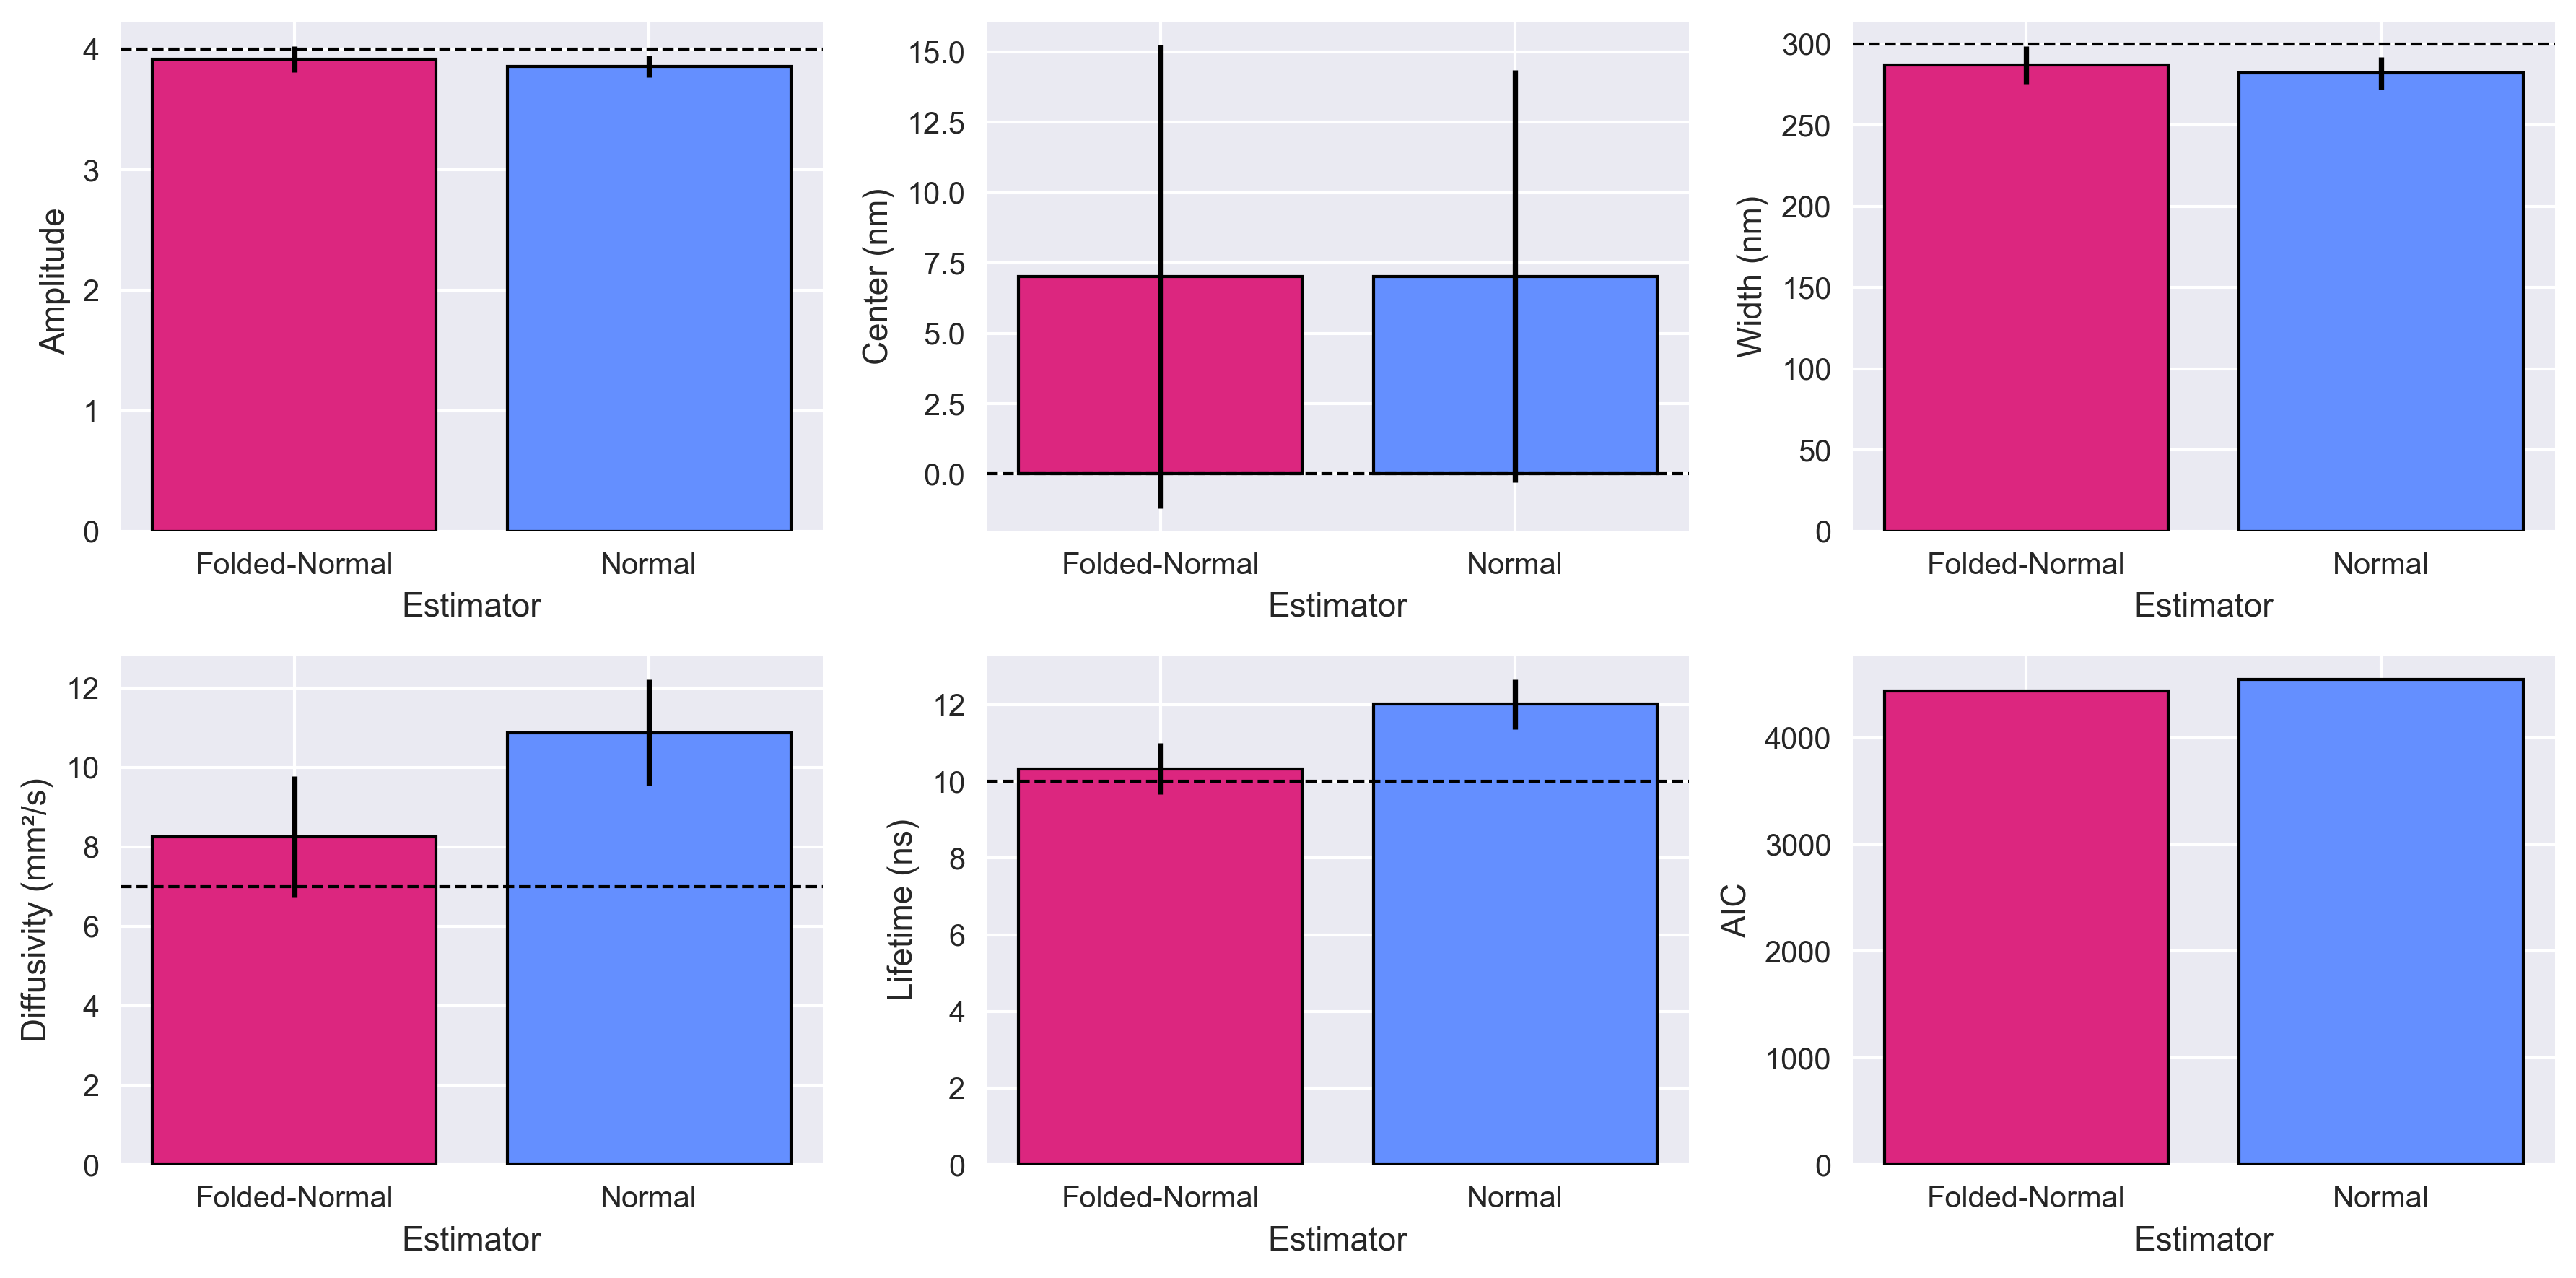

In [16]:
# plot the estimated parameters, their uncertainties, and the AIC
estimator_names = list(estimator.keys())
estimator_colors = [red, blue]

parameter_names = ["Amplitude", "Center", "Width", "Diffusivity", "Lifetime"]
parameter_units = ["", "(nm)", "(nm)", "(mm²/s)", "(ns)"]
parameter_scaling = [1e4, 1e9, 1e9, 1e6, 1e9]

fig, axs = plt.subplots(
    2, (len(params_true) + 1) // 2, figsize=((len(params_true) + 1) // 2 * 4, 2 * 3)
)
for ii in range(len(params_true)):
    values = np.array([params[name][ii] for name in estimator_names])
    errors = np.sqrt([param_covs[name][ii, ii] for name in estimator_names])

    row, col = 2 * ii // (len(params_true) + 1), ii % ((len(params_true) + 1) // 2)

    axs[row, col].bar(
        estimator_names,
        parameter_scaling[ii] * values,
        yerr=parameter_scaling[ii] * errors,
        linewidth=1,
        facecolor=estimator_colors,
        edgecolor=black,
    )

    axs[row, col].axhline(
        parameter_scaling[ii] * params_true[ii],
        linewidth=1,
        linestyle="--",
        color=black,
    )

    axs[row, col].set_xlabel("Estimator")
    axs[row, col].set_ylabel(parameter_names[ii] + " " + parameter_units[ii])

axs[1, -1].bar(
    estimator_names,
    aic.values(),
    linewidth=1,
    facecolor=estimator_colors,
    edgecolor=black,
)

axs[1, -1].set_ylabel("AIC")
axs[1, -1].set_xlabel("Estimator")

fig.tight_layout()

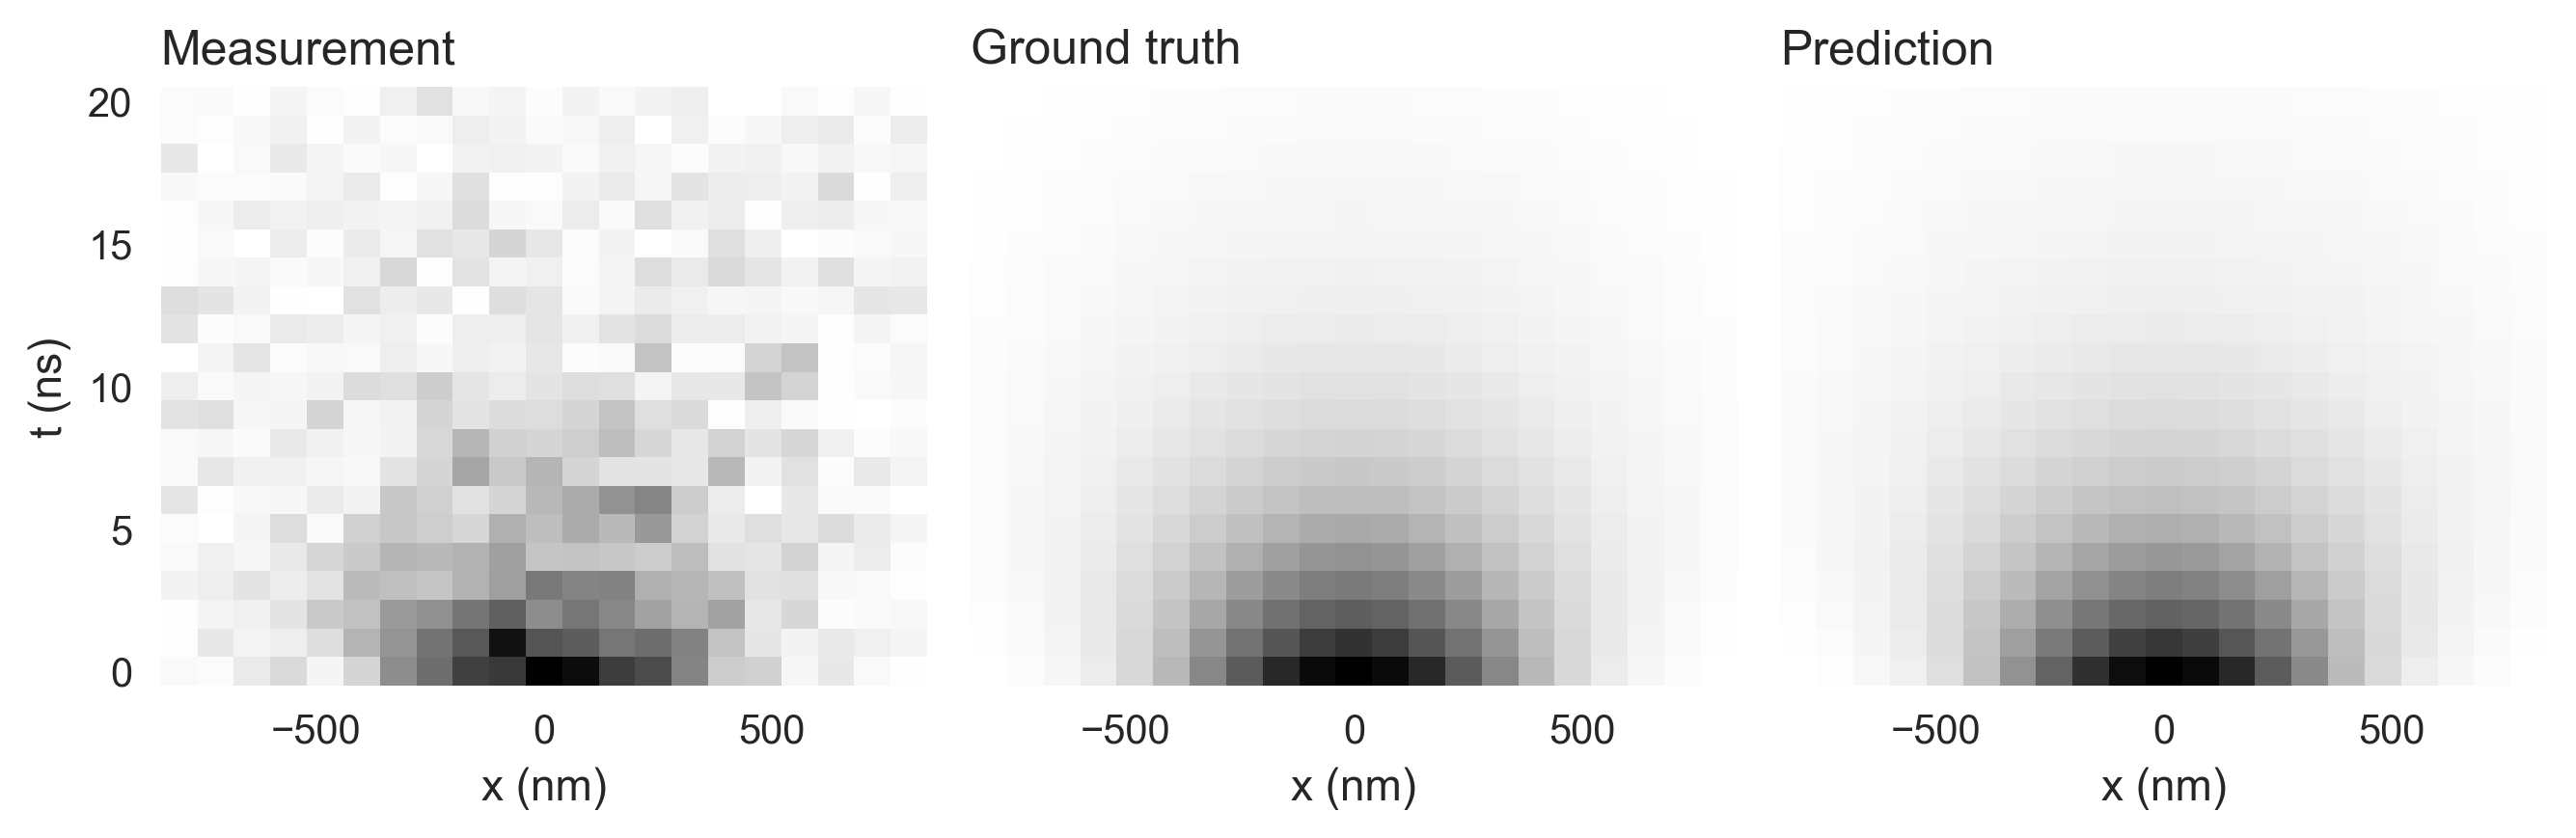

In [17]:
# show the fit
fig, axs = plt.subplots(1, 3, figsize=(9, 3), sharex=True, sharey=True)

axs[0].pcolormesh(1e9 * x_data, 1e9 * t_data, y_data)
axs[1].pcolormesh(1e9 * x_data, 1e9 * t_data, f_x_t)
axs[2].pcolormesh(1e9 * x_data, 1e9 * t_data, y_pred["Folded-Normal"])

axs[0].set_xlabel("x (nm)")
axs[1].set_xlabel("x (nm)")
axs[2].set_xlabel("x (nm)")
axs[0].set_ylabel("t (ns)")

axs[0].set_title("Measurement", loc="left")
axs[1].set_title("Ground truth", loc="left")
axs[2].set_title("Prediction", loc="left")

fig.tight_layout()

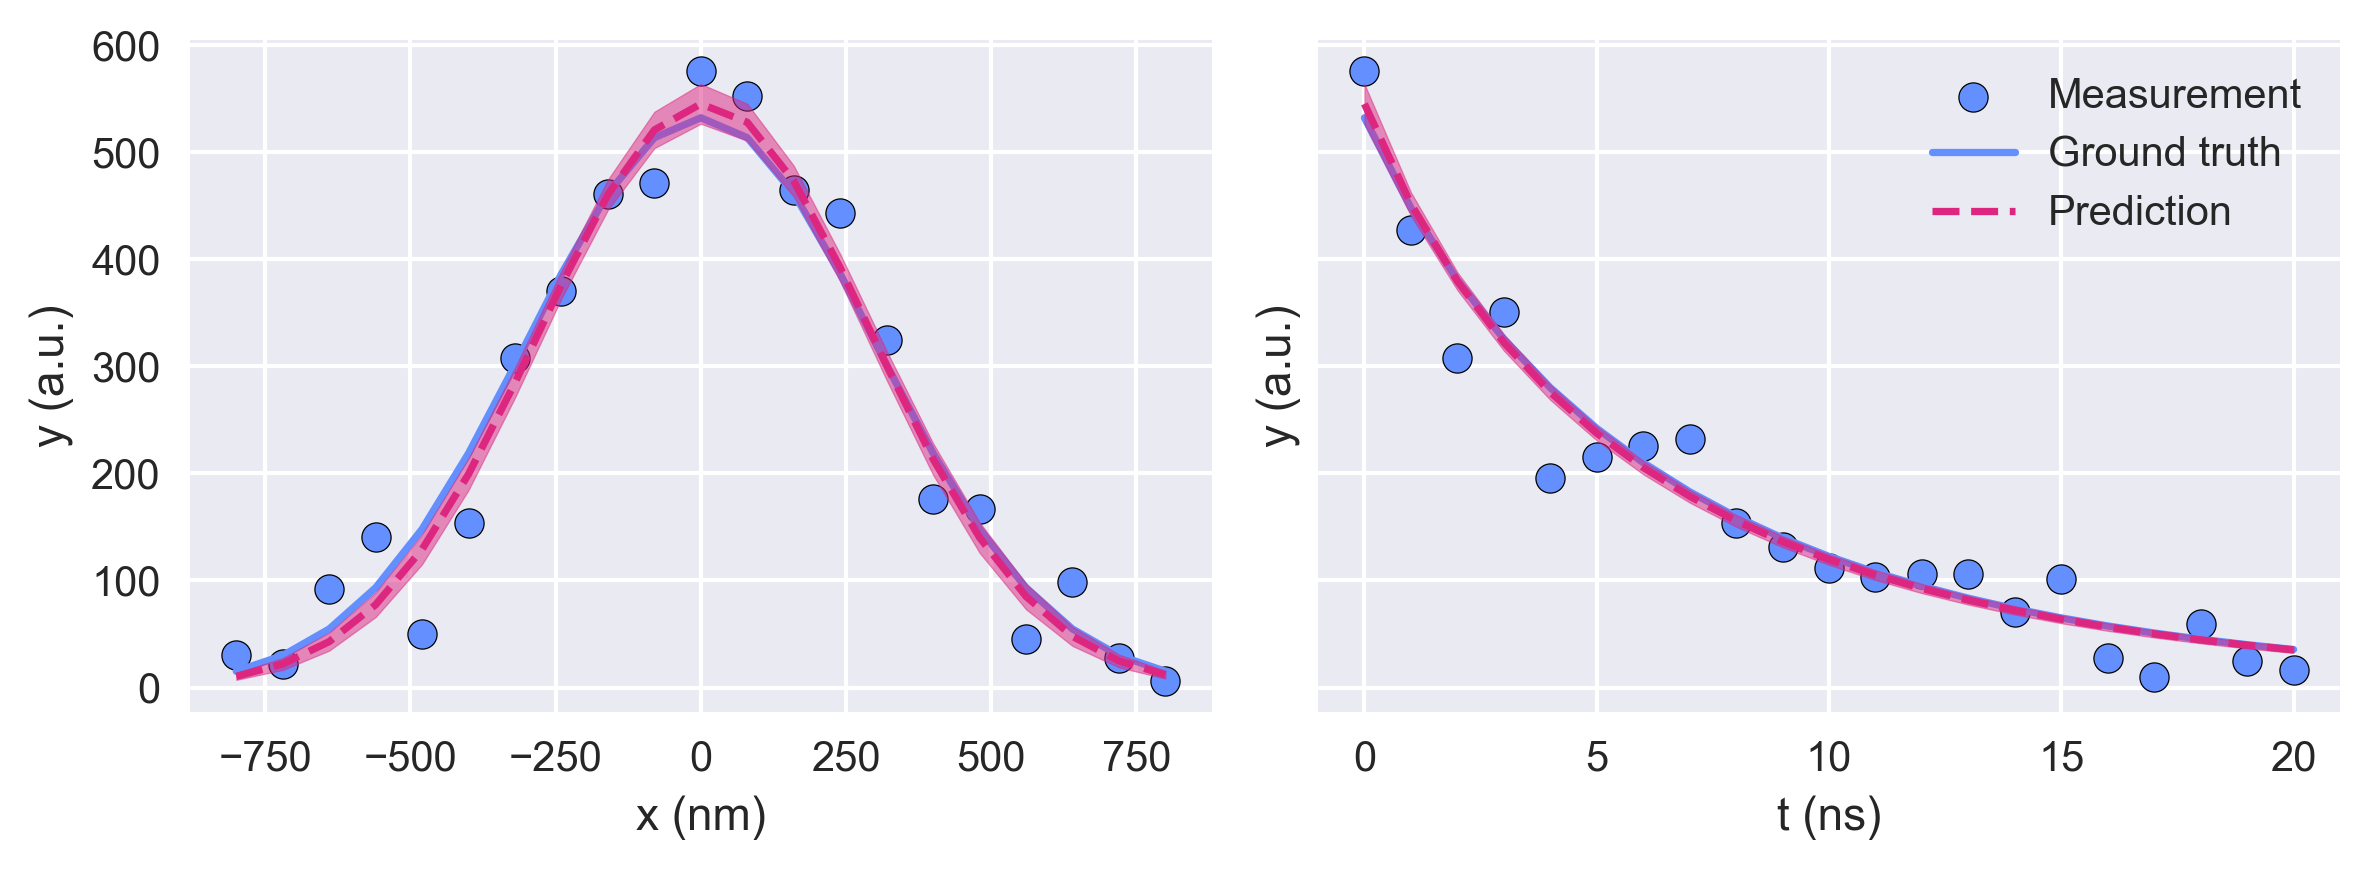

In [18]:
# show the fit
fig, axs = plt.subplots(1, 2, figsize=(2 * 4, 3), sharex=False, sharey=True)

axs[0].scatter(
    1e9 * x_data[0, :],
    y_data[0, :],
    label="Measurement",
    edgecolor=black,
    facecolor=blue,
    zorder=5,
)
axs[0].plot(
    1e9 * x_data[0, :], f_x_t[0, :], label="Ground truth", color=blue, zorder=10
)
axs[0].plot(
    1e9 * x_data[0, :],
    y_pred["Folded-Normal"][0, :],
    label="Prediction",
    linestyle="--",
    color=red,
    zorder=20,
)
axs[0].fill_between(
    1e9 * x_data[0, :],
    y_pred["Folded-Normal"][0, :] - y_err["Folded-Normal"][0, :],
    y_pred["Folded-Normal"][0, :] + y_err["Folded-Normal"][0, :],
    color=red,
    alpha=0.5,
    zorder=15,
)

axs[1].scatter(
    1e9 * t_data[:, n_x // 2],
    y_data[:, n_x // 2],
    label="Measurement",
    edgecolor=black,
    facecolor=blue,
    zorder=5,
)
axs[1].plot(
    1e9 * t_data[:, n_x // 2],
    f_x_t[:, n_x // 2],
    label="Ground truth",
    color=blue,
    zorder=10,
)
axs[1].plot(
    1e9 * t_data[:, n_x // 2],
    y_pred["Folded-Normal"][:, n_x // 2],
    label="Prediction",
    linestyle="--",
    color=red,
    zorder=20,
)
axs[1].fill_between(
    1e9 * t_data[:, n_x // 2],
    y_pred["Folded-Normal"][:, n_x // 2] - y_err["Folded-Normal"][:, n_x // 2],
    y_pred["Folded-Normal"][:, n_x // 2] + y_err["Folded-Normal"][:, n_x // 2],
    color=red,
    alpha=0.5,
    zorder=15,
)

axs[0].set_xlabel("x (nm)")
axs[0].set_ylabel("y (a.u.)")

axs[1].set_xlabel("t (ns)")
axs[1].set_ylabel("y (a.u.)")
axs[1].legend()

fig.tight_layout()